In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
df = pd.read_csv('CreditScoring.csv')

----Data Preparation

In [3]:
df.columns = df.columns.str.lower()

In [4]:
df.head(5)

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [5]:
df.shape

(4455, 14)

---- --Turn Categorical columns values from numbers to strings

In [6]:
# these tuples come from zoomcamp for ml github repository
status = ("no", "yes", "unk")
home = ("rent", "owner", "priv", "ignore", "parents", "other", "unk")
marital = ("single", "married", "widow", "separated", "divorced", "unk")
records = ("no_rec", "yes_rec", "unk")
job = ("fixed", "partime", "freelance", "others", "unk")

categorical_col_var = [status, home, marital, records, job]
categorical_col_df = ['status', 'home', 'marital', 'records', 'job']

In [7]:
for i in range(len(categorical_col_var)):
    col_val = df[categorical_col_df[i]].unique()
    col_val = col_val[col_val != 0]
    col_val = np.sort(col_val)
    col_val = np.append(col_val, 0)
    map_dict = dict(zip(col_val, categorical_col_var[i]))
    df[categorical_col_df[i]] = df[categorical_col_df[i]].map(map_dict)

In [8]:
df.head(5)

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,no,9,rent,60,30,married,no_rec,freelance,73,129,0,0,800,846
1,no,17,rent,60,58,widow,no_rec,fixed,48,131,0,0,1000,1658
2,yes,10,owner,36,46,married,yes_rec,freelance,90,200,3000,0,2000,2985
3,no,0,rent,60,24,single,no_rec,fixed,63,182,2500,0,900,1325
4,no,0,rent,36,26,single,no_rec,fixed,46,107,0,0,310,910


In [9]:
for col in categorical_col_df:
    print(f'{col}: {df[col].unique()}')

status: <StringArray>
['no', 'yes', 'unk']
Length: 3, dtype: str
home: <StringArray>
['rent', 'owner', 'parents', 'priv', 'other', 'ignore', 'unk']
Length: 7, dtype: str
marital: <StringArray>
['married', 'widow', 'single', 'separated', 'divorced', 'unk']
Length: 6, dtype: str
records: <StringArray>
['no_rec', 'yes_rec']
Length: 2, dtype: str
job: <StringArray>
['freelance', 'fixed', 'partime', 'unk', 'others']
Length: 5, dtype: str


In [10]:
df = df[df.status != 'unk'].reset_index(drop= True)

In [11]:
df.status.value_counts()

status
no     3200
yes    1254
Name: count, dtype: int64

----Numerical Columns

In [12]:
numerical_col_df = [col for col in df.columns if col not in categorical_col_df]

In [13]:
numerical_col_df

['seniority',
 'time',
 'age',
 'expenses',
 'income',
 'assets',
 'debt',
 'amount',
 'price']

In [14]:
df[numerical_col_df].describe()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4454.000000,4454.000000,4454.000000,4454.000000,4.454000e+03,4.454000e+03,4.454000e+03,4454.000000,4454.000000
mean,7.986753,46.438707,37.080377,55.573417,7.634883e+05,1.060578e+06,4.044728e+05,1038.918276,1462.780198
std,8.174306,14.655462,10.984598,19.515634,8.704595e+06,1.021870e+07,6.344963e+06,474.545999,628.128120
min,0.000000,6.000000,18.000000,35.000000,0.000000e+00,0.000000e+00,0.000000e+00,100.000000,105.000000
25%,2.000000,36.000000,28.000000,35.000000,8.000000e+01,0.000000e+00,0.000000e+00,700.000000,1117.250000
50%,5.000000,48.000000,36.000000,51.000000,1.200000e+02,3.500000e+03,0.000000e+00,1000.000000,1400.000000
75%,12.000000,60.000000,45.000000,72.000000,1.660000e+02,6.000000e+03,0.000000e+00,1300.000000,1691.500000
max,48.000000,72.000000,68.000000,180.000000,1.000000e+08,1.000000e+08,1.000000e+08,5000.000000,11140.000000


In [15]:
outlier_value = max(df[numerical_col_df].max())
for col in numerical_col_df:
    df[col] = df[col].replace(to_replace= outlier_value, value= np.nan)

In [16]:
df.home[df.home == 'unk'].count()

np.int64(6)

----Unknown and Missing Values

In [17]:
total_missing_values = df.isna().any(axis= 1).sum() + (df == 'unk').any(axis= 1).sum()

In [18]:
print(f'the total missinng values is: {round(100 * total_missing_values / df.shape[0], 2)}% of df')

the total missinng values is: 1.91% of df


In [19]:
df = df[~((df.isna().any(axis= 1)) | ((df == 'unk').any(axis= 1)))]

In [20]:
df = df.reset_index(drop= True)

----Split the DataSet

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
full_train_set, test_set = train_test_split(df, test_size= 0.2, stratify= df.status, random_state= 1)
full_train_set = full_train_set.reset_index(drop= True)
train_set, val_set = train_test_split(full_train_set, test_size= 0.25, stratify= full_train_set.status, random_state= 1)

In [23]:
train_set = train_set.reset_index(drop= True)
val_set = val_set.reset_index(drop= True)
test_set = test_set.reset_index(drop= True)

In [24]:
y_full_train = full_train_set.status.map({'no':0, 'yes':1}).values
y_train = train_set.status.map({'no':0, 'yes':1}).values
y_val = val_set.status.map({'no':0, 'yes':1}).values
y_test = test_set.status.map({'no':0, 'yes':1}).values

----Training A Decision Tree Model

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, roc_auc_score

In [26]:
ct = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical_col_df[1:])],
    remainder= 'passthrough')

In [27]:
X_train = ct.fit_transform(train_set.iloc[:, 1:])

In [28]:
X_val = ct.transform(val_set.iloc[:, 1:])
X_test = ct.transform(test_set.iloc[:, 1:])

In [29]:
model = DecisionTreeClassifier(random_state= 1)

In [30]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [31]:
print(f'accuracy on validation set: {accuracy_score(y_val, model.predict(X_val)):.2f}')
print(f'auc_score on validation set: {roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]):.2f}')
print('--------------------------------')
print(f'auc_score on train set: {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]):.2f}')      # (1)

accuracy on validation set: 0.70
auc_score on validation set: 0.64
--------------------------------
auc_score on train set: 1.00


In [32]:
%%capture
print(export_text(model, feature_names= ct.get_feature_names_out()))                                    #(2)

In [33]:
""" From (1) & (2) there is a suspicion of OVERFITTING(high Variance). The model memorise every possible pattern in train set
    but underperform on validation set. Next step is Hyperparameter Tuning"""

' From (1) & (2) there is a suspicion of OVERFITTING(high Variance). The model memorise every possible pattern in train set\n    but underperform on validation set. Next step is Hyperparameter Tuning'

----Tuning Parameters

In [34]:
max_depth_list = [None] + [i for i in range(1, 10)]
min_samples_leaf_list = [i for i in range(1, 10)] + [i for i in range(10, 210, 10)]

In [35]:
auc_score_md = []
for d in max_depth_list:
    dt = DecisionTreeClassifier(max_depth= d, random_state= 1)
    dt.fit(X_train, y_train)
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    auc_score_md.append({'auc': auc, 'depth': d})

In [36]:
auc_score_df = pd.DataFrame(auc_score_md)
auc_score_df.auc = auc_score_df.auc.astype('float')

In [37]:
top_3_depth = auc_score_df.nlargest(3, 'auc').depth.astype('int')
top_3_depth

5    5
4    4
7    7
Name: depth, dtype: int64

In [38]:
auc_score_md_ms = []
for d in top_3_depth:
    for s in min_samples_leaf_list:
        dt = DecisionTreeClassifier(max_depth= d, min_samples_leaf= s, random_state= 1)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        auc_score_md_ms.append({'auc': auc, 'depth': d, 'leaf_sample': s})

In [39]:
auc_df = pd.DataFrame(auc_score_md_ms)
auc_df.auc = auc_df.auc.astype('float')

In [40]:
best_parameters = auc_df[auc_df.auc == auc_df.auc.max()]
best_parameters

,auc,depth,leaf_sample
73,0.799086,7,70


In [41]:
pivot_df = auc_df.pivot(index= 'leaf_sample', columns= ['depth'], values= ['auc'])

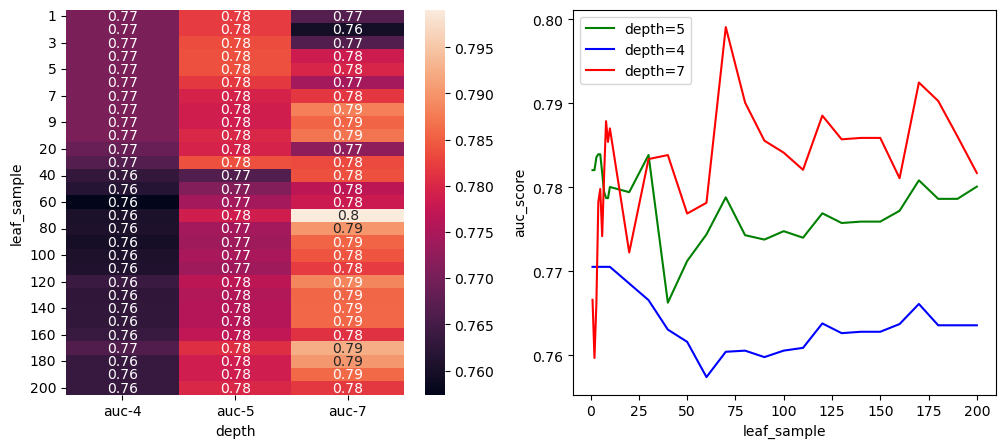

In [42]:
fig, ax = plt.subplots(1, 2, figsize= (12, 5))
sn.heatmap(pivot_df, annot= True, ax= ax[0])
ax[0].set_xlabel('depth')
color = ['green', 'blue', 'red']
for d, c in zip(top_3_depth, color):
    ax[1].plot(auc_df.leaf_sample[auc_df.depth == d], auc_df.auc[auc_df.depth == d], color = c, label= f'depth={d}')
ax[1].set_ylabel('auc_score')
ax[1].set_xlabel('leaf_sample')
ax[1].legend()
plt.show()

----Save data for Cross Validation

In [46]:
full_train_set.to_csv('full_train_set.csv')
test_set.to_csv('test_data_set.csv')

In [44]:
categorical_col_df

['status', 'home', 'marital', 'records', 'job']